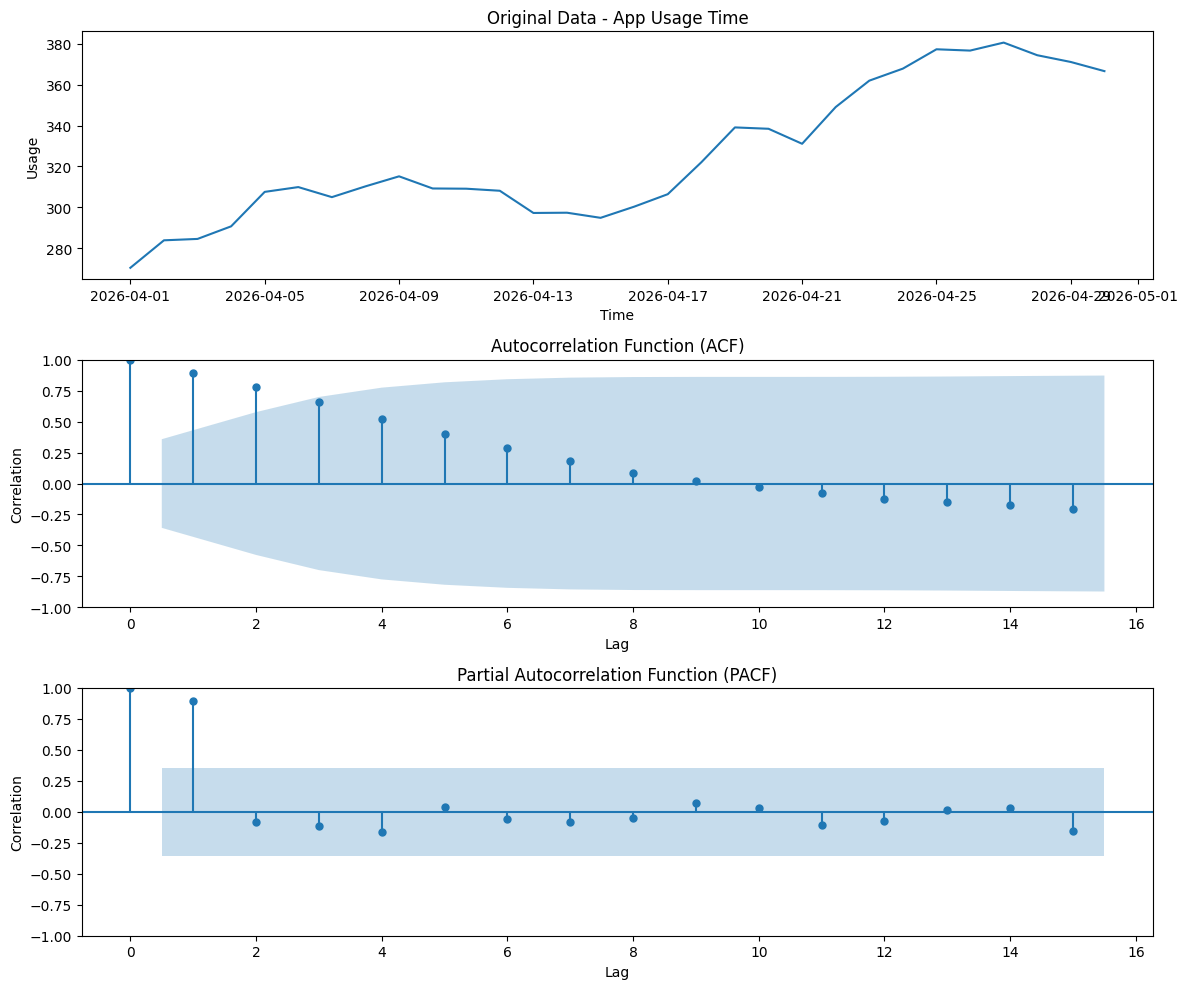

c:\PROJECT\TSA\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\PROJECT\TSA\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\PROJECT\TSA\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


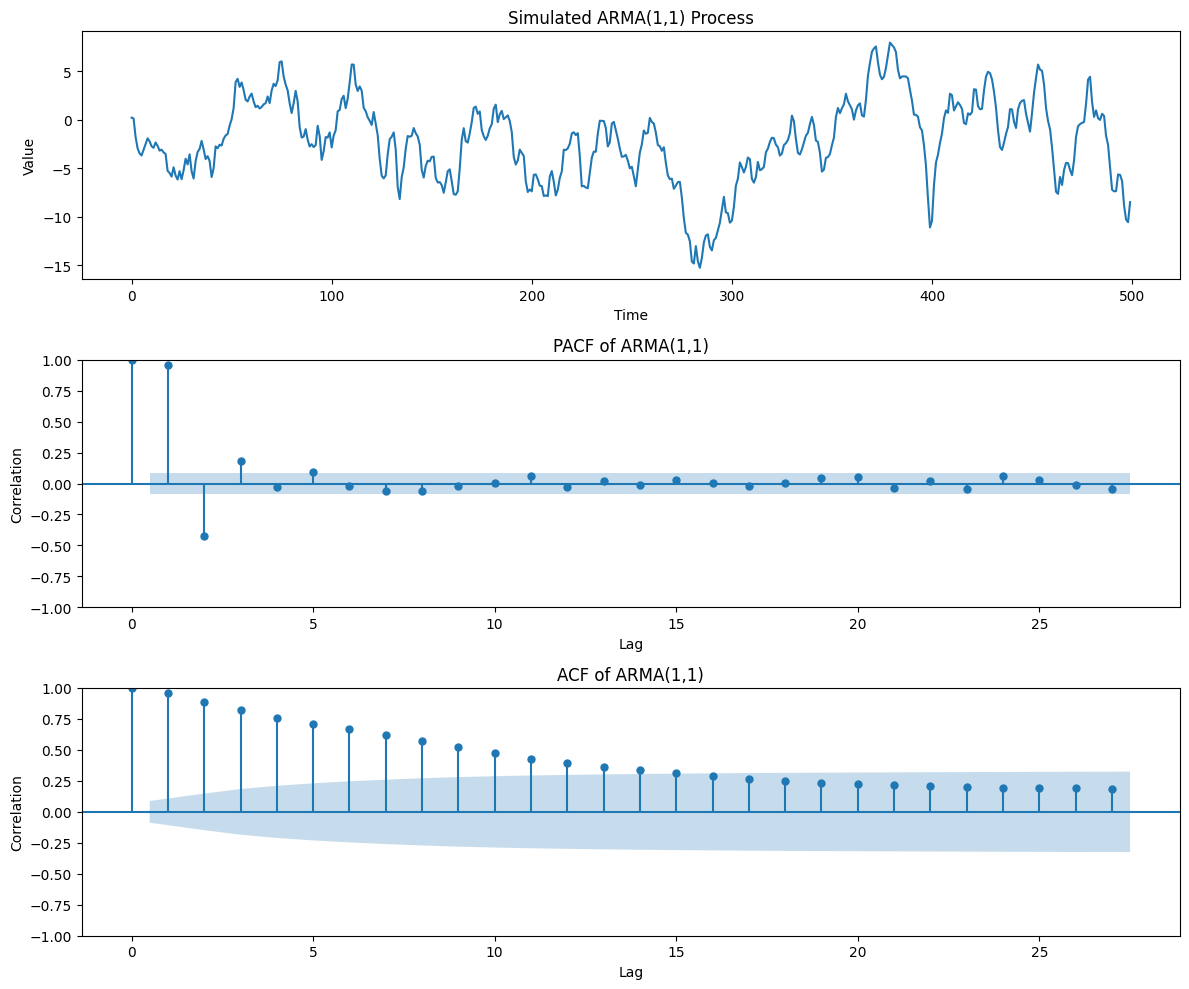

c:\PROJECT\TSA\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\PROJECT\TSA\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\PROJECT\TSA\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


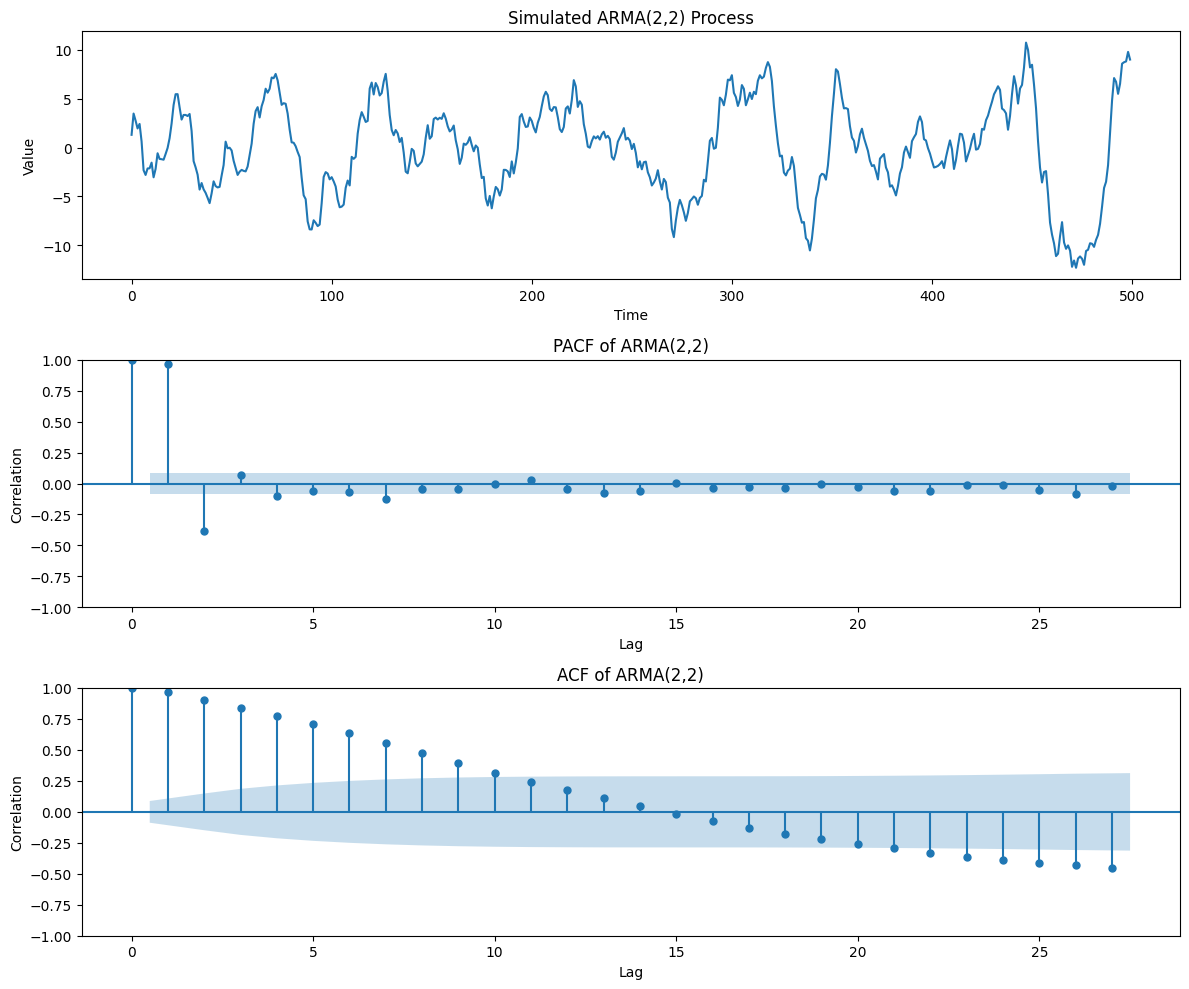

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


data = pd.read_csv("user_behavior_timeseries.csv")
data.columns = data.columns.str.strip()

data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

data = data.groupby('Date').mean(numeric_only=True)

X = data["App Usage Time"]


trend = np.linspace(0, 100, len(X))
seasonal = 20 * np.sin(np.linspace(0, 3*np.pi, len(X)))
noise = np.random.normal(0, 5, len(X))

X = X + trend + seasonal + noise


plt.figure(figsize=(12,10))

# Original Data
plt.subplot(3,1,1)
plt.plot(X)
plt.title("Original Data - App Usage Time")
plt.xlabel("Time")
plt.ylabel("Usage")

# ACF
plt.subplot(3,1,2)
plot_acf(X, lags=15, ax=plt.gca())
plt.title("Autocorrelation Function (ACF)")
plt.xlabel("Lag")
plt.ylabel("Correlation")

# PACF
plt.subplot(3,1,3)
plot_pacf(X, lags=15, ax=plt.gca())
plt.title("Partial Autocorrelation Function (PACF)")
plt.xlabel("Lag")
plt.ylabel("Correlation")

plt.tight_layout()
plt.show()


model1 = ARIMA(X, order=(1,0,1)).fit()

phi = model1.params['ar.L1']
theta = model1.params['ma.L1']

ar = np.array([1, -phi])
ma = np.array([1, theta])

arma1 = ArmaProcess(ar, ma).generate_sample(nsample=500)

plt.figure(figsize=(12,10))

# ARMA Signal
plt.subplot(3,1,1)
plt.plot(arma1)
plt.title("Simulated ARMA(1,1) Process")
plt.xlabel("Time")
plt.ylabel("Value")

# PACF
plt.subplot(3,1,2)
plot_pacf(arma1, ax=plt.gca())
plt.title("PACF of ARMA(1,1)")
plt.xlabel("Lag")
plt.ylabel("Correlation")

# ACF
plt.subplot(3,1,3)
plot_acf(arma1, ax=plt.gca())
plt.title("ACF of ARMA(1,1)")
plt.xlabel("Lag")
plt.ylabel("Correlation")

plt.tight_layout()
plt.show()

model2 = ARIMA(X, order=(2,0,2)).fit()

phi1 = model2.params['ar.L1']
phi2 = model2.params['ar.L2']
theta1 = model2.params['ma.L1']
theta2 = model2.params['ma.L2']

ar = np.array([1, -phi1, -phi2])
ma = np.array([1, theta1, theta2])

arma2 = ArmaProcess(ar, ma).generate_sample(nsample=500)

plt.figure(figsize=(12,10))

# ARMA Signal
plt.subplot(3,1,1)
plt.plot(arma2)
plt.title("Simulated ARMA(2,2) Process")
plt.xlabel("Time")
plt.ylabel("Value")

# PACF
plt.subplot(3,1,2)
plot_pacf(arma2, ax=plt.gca())
plt.title("PACF of ARMA(2,2)")
plt.xlabel("Lag")
plt.ylabel("Correlation")

# ACF
plt.subplot(3,1,3)
plot_acf(arma2, ax=plt.gca())
plt.title("ACF of ARMA(2,2)")
plt.xlabel("Lag")
plt.ylabel("Correlation")

plt.tight_layout()
plt.show()